## Insurance Dataset — EDA & Preprocessing
📌 Dataset Overview

This dataset contains information about individuals and their medical insurance costs. It includes demographic, health-related, and regional attributes that may influence medical expenses.

📊 Features
Age — Age of the individual
Sex — Gender of the individual
BMI — Body Mass Index
Children — Number of dependents/children
Smoker — Smoking status
Region — Residential region
Charges — Individual medical insurance cost (Target Variable)
🎯 Objective

The main objective is to explore the dataset, understand the relationships between the features and medical charges, identify data-quality issues, and prepare the data for machine-learning modeling.

### Data Understanding

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [4]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.shape

(1338, 7)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Checking Data Types

In [10]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [21]:
dtype = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({"Dtype" : dtype, "N_uniques" : n_uniq}).T

,age,sex,bmi,children,smoker,region,charges
Dtype,int64,str,float64,int64,str,str,float64
N_uniques,47,2,548,6,2,4,1337


### checking nulls

In [11]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [22]:
null = df.isnull().sum()

ratio = (null / df.shape[0])*100

pd.DataFrame({"null" : null, "ratio" : ratio}).T

,age,sex,bmi,children,smoker,region,charges
null,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### check Outliers 

In [13]:
numerical_cols = ['age', 'bmi', 'children', 'charges']
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df[
    ((df[numerical_cols] < lower_fence) |
     (df[numerical_cols] > upper_fence)).any(axis=1)
]

outliers

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600
1317,18,male,53.130,0,no,southeast,1163.46270


In [14]:
outlier_counts = {}

for col in numerical_cols:
    outlier_counts[col] = (
        (df[col] < lower_fence[col]) |
        (df[col] > upper_fence[col])
    ).sum()

outlier_counts

{'age': np.int64(0),
 'bmi': np.int64(9),
 'children': np.int64(0),
 'charges': np.int64(139)}

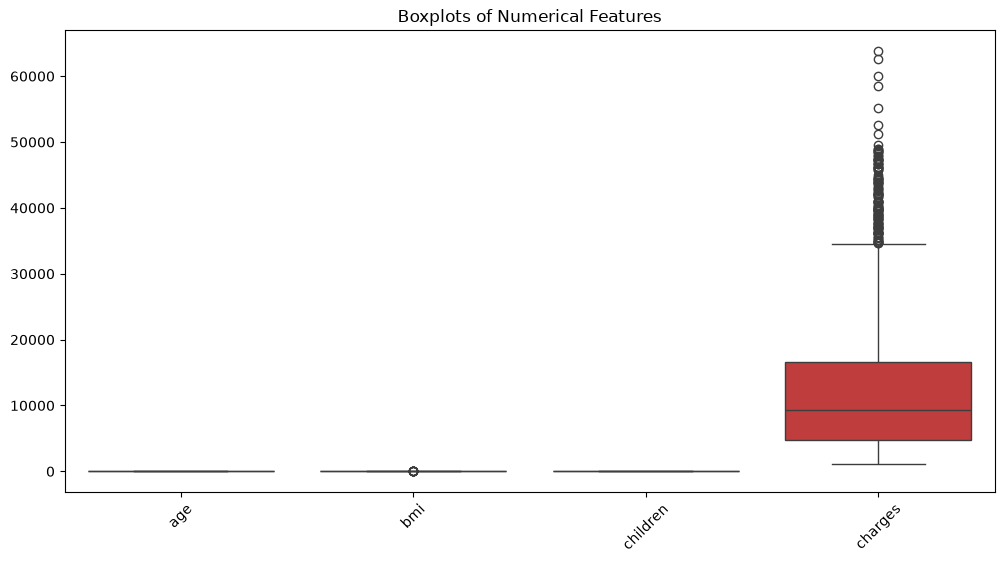

In [15]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[numerical_cols])

plt.title('Boxplots of Numerical Features')
plt.xticks(rotation=45)
plt.show()

### checking and handling duplicates

In [17]:
df.duplicated().sum()

np.int64(1)

In [18]:
df = df.drop_duplicates()

## Visualization

#### Numerical distributions

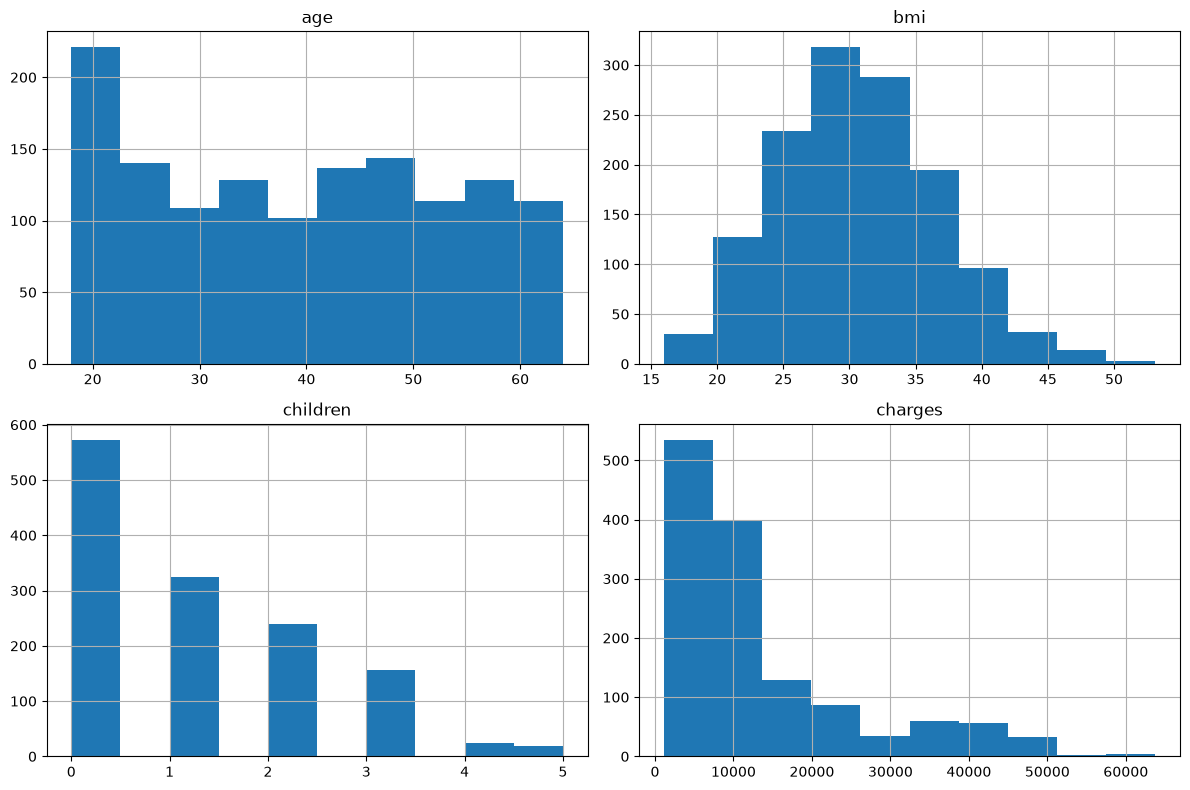

In [19]:
df[numerical_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

#### Categorical feature distributions


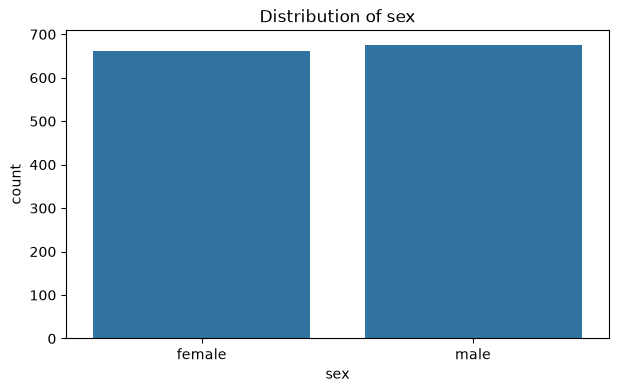

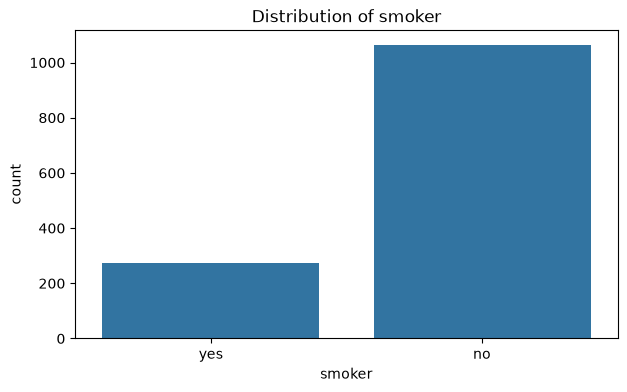

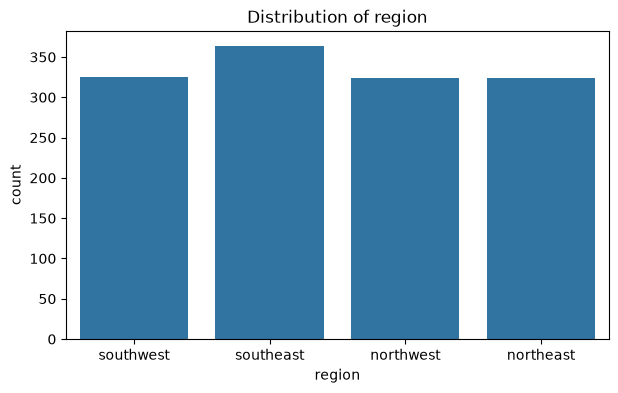

In [32]:
categorical_cols = ['sex', 'smoker', 'region']

for col in categorical_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.show()

### handling outliers

In [23]:
df['charges'] = np.log1p(df['charges'])


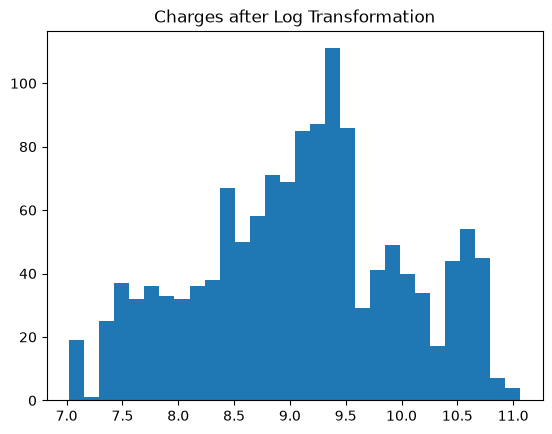

In [24]:
plt.hist(df['charges'], bins=30)
plt.title('Charges after Log Transformation')
plt.show()

In [25]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['bmi'] = df['bmi'].clip(lower_bound, upper_bound)



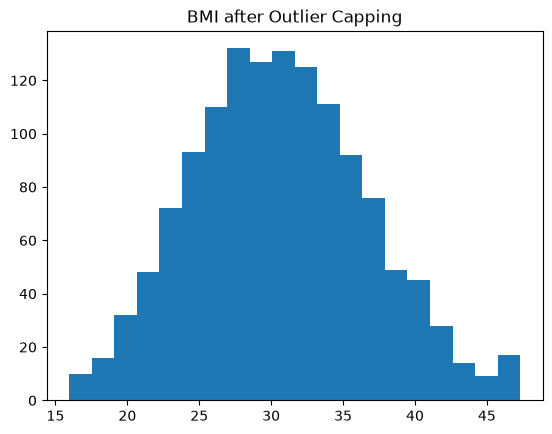

In [26]:
plt.hist(df['bmi'], bins=20)
plt.title('BMI after Outlier Capping')
plt.show()

### EDA & Visualization

#### Does age affect medical charges?

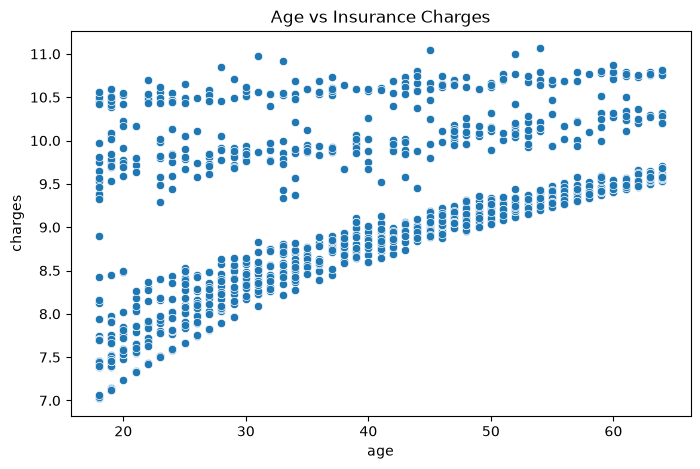

In [27]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='age', y='charges')

plt.title('Age vs Insurance Charges')
plt.show()

#### Does BMI affect medical charges?

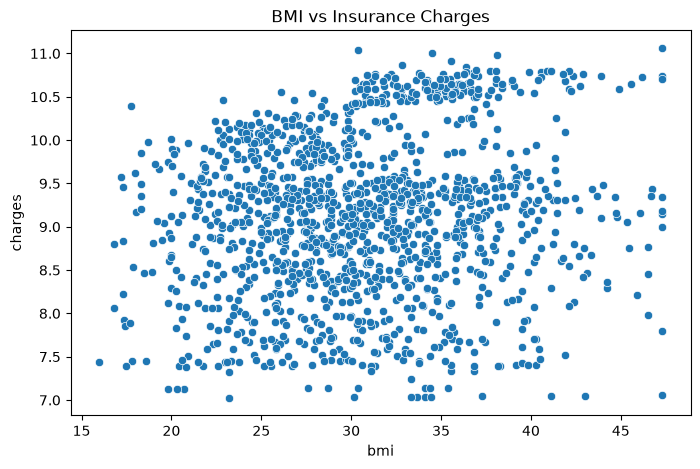

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='bmi', y='charges')

plt.title('BMI vs Insurance Charges')
plt.show()

#### Does smoking status affect medical charges?

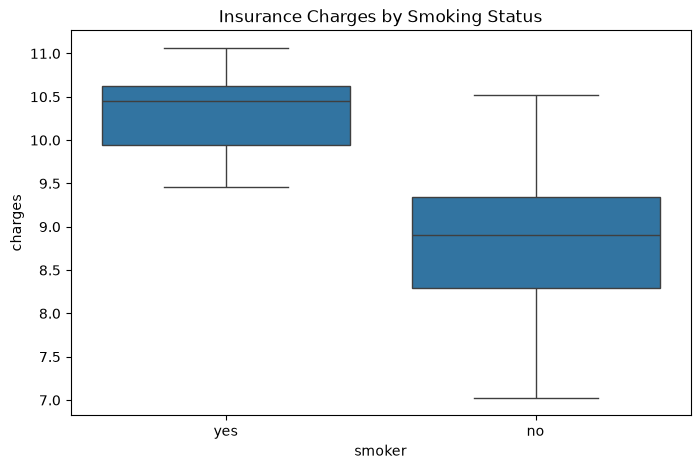

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='smoker', y='charges')

plt.title('Insurance Charges by Smoking Status')
plt.show()

In [30]:
df.groupby('smoker')['charges'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
smoker,,,,
no,8.789740,8.902010,7.023647,10.516281
yes,10.304146,10.447477,9.459577,11.063061


#### Does sex have a noticeable relationship with charges?

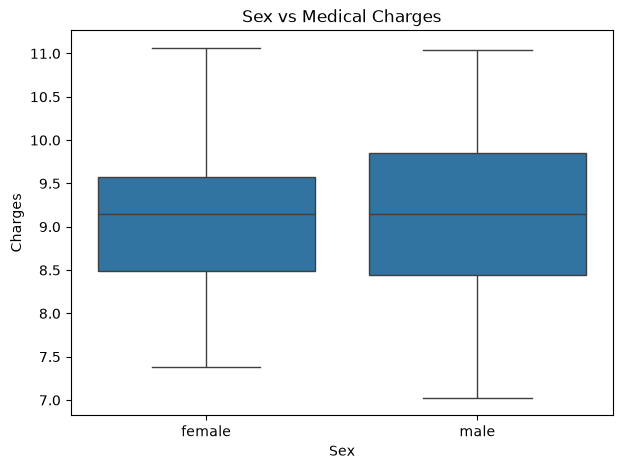

In [33]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='sex', y='charges')
plt.title('Sex vs Medical Charges')
plt.xlabel('Sex')
plt.ylabel('Charges')
plt.show()

#### Does region affect medical charges?

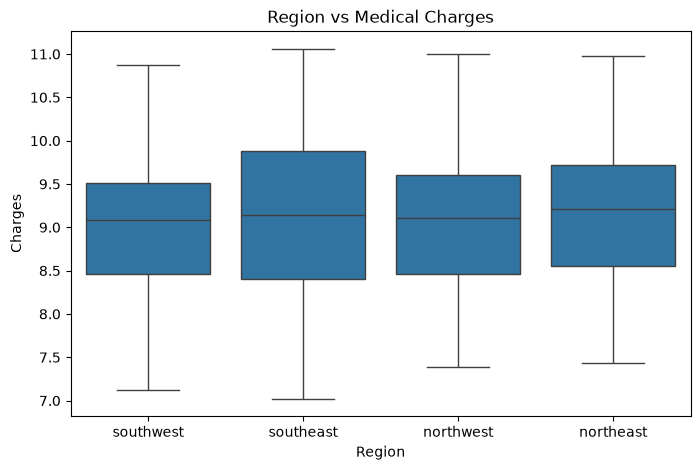

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='region', y='charges')
plt.title('Region vs Medical Charges')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()

#### Does the number of children relate to medical charges?

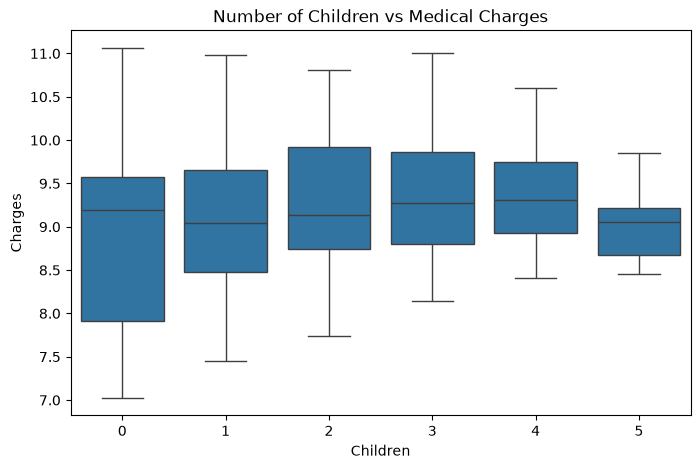

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='children', y='charges')
plt.title('Number of Children vs Medical Charges')
plt.xlabel('Children')
plt.ylabel('Charges')
plt.show()

#### correlation heat map between features

In [36]:
df_corr = df.copy()

df_corr['sex'] = df_corr['sex'].map({
    'male': 1,
    'female': 0
})

df_corr['smoker'] = df_corr['smoker'].map({
    'yes': 1,
    'no': 0
})

df_corr = pd.get_dummies(
    df_corr,
    columns=['region'],
    drop_first=True
)

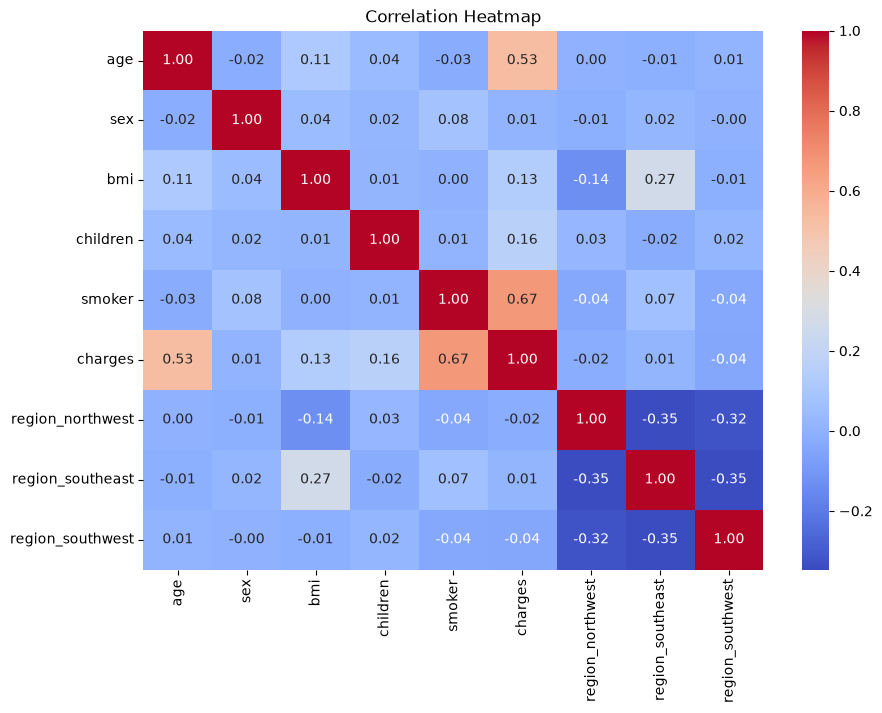

In [37]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df_corr.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()